In [1]:
from misc_utils import hadamard_transform
import numpy as np
import matplotlib.pyplot as plt
from spin_lattices import KagomeLattice
from spin_systems import (
    heisenberg,
    heisenberg_transversal_field,
    heisenberg_str,
    spin_system,
    no_symmetries_basis,
    zero_sector_basis,
)
import pandas as pd
import seaborn as sns
import numpy.typing as npt
import lattice_symmetries as ls
import loguru
from tqdm.auto import tqdm
from ising_sign_reconstruction import custom_signs_hadamard_spread
from spin_systems import zero_sector_basis
from spin_lattices import SpinLattice, KagomeLattice, SquareLattice, TriangularLattice
from kagome_round import get_kagome36

# from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
import numpy.typing as npt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from misc_utils import hadamard_transform
import torch
import unittest
from tqdm.auto import tqdm
from fourier_supervised_cleanroom_2023_09_27 import (
    get_config,
    output_dir,
    default_config,
)
from misc_utils import read_jsonl_to_df, keep_serializable, column_to
from nn_supervised_reproduction import (
    output_dir as nn_output_dir,
    default_config as nn_default_config,
)
from scipy.special import comb
from hadamard_learning import evaluate_hadamard_learning_test_set
from tqdm.auto import tqdm

In [4]:
df_nn = read_jsonl_to_df(nn_output_dir.glob("*/results.jsonl")).fillna(
    keep_serializable(nn_default_config)
)

/tmp/nix-shell.pzUmzv/ipykernel_3818877/2232928704.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_nn = read_jsonl_to_df(nn_output_dir.glob("*/results.jsonl")).fillna(


In [9]:
df_nn["lattice"].unique()

array(['square6x6', 'triangular6x6', 'kagome2x4', 'square6x4',
       'square4x6', 'triangular6x4', 'triangular5x5', 'triangular4x4',
       'square5x5', 'square5x4'], dtype=object)

In [10]:
sample_power = 2
# lattice = KagomeLattice(2, 4)
outputs = []
for lattice, lattice_name in [
    (KagomeLattice(2, 4), "kagome2x4"),
    (SquareLattice(6, 4), "square6x4"),
    (TriangularLattice(6, 4), "triangular6x4"),
]:
    J2s = df_nn.query("architecture == 'dense' and lattice == @lattice_name")[
        "J2"
    ].unique()
    for J2 in tqdm(J2s):
        system = spin_system(
            heisenberg(lattice, J2=J2), no_symmetries_basis(hamming_weight=None)
        )
        invariant_ground_state = (
            hadamard_transform(system.ground_state) + system.ground_state
        ) / 2
        transformed_invariant_ground_state = hadamard_transform(invariant_ground_state)
        hamiltonian_transformed_invariant_ground_state = (
            system.hamiltonian @ invariant_ground_state
        )
        for eps_train in [1e-5, 1e-4, 1e-3, 1e-2]:
            outputs.append(
                evaluate_hadamard_learning_test_set(
                    wavefunction=invariant_ground_state,
                    basis=system.basis,
                    sample_power=sample_power,
                    test_size=50000,
                    eps_train=eps_train,
                )
                | {
                    "J2": J2,
                    "lattice": lattice_name,
                    "overlap_with_transformed": invariant_ground_state
                    @ transformed_invariant_ground_state
                    / np.linalg.norm(invariant_ground_state)
                    / np.linalg.norm(transformed_invariant_ground_state),
                    "overlap_with_hamiltonian_transformed": invariant_ground_state
                    @ hamiltonian_transformed_invariant_ground_state
                    / np.linalg.norm(invariant_ground_state)
                    / np.linalg.norm(hamiltonian_transformed_invariant_ground_state),
                }
            )
df_hadamard = pd.DataFrame(outputs)

  0%|          | 0/11 [00:00<?, ?it/s]

2025-01-14 16:56:25.411 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2025-01-14 16:56:25.413 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2025-01-14 16:56:25.470 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2025-01-14 16:56:25.635 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2025-01-14 16:56:25.743 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2025-01-14 16:56:25.824 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2025-01-14 16:56:25.894 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2025-01-14 16:56:25.962 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2025-01-14 16:56:26.039 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2025-01-14 16:56:26.115 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2025-0

0it [00:00, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

2025-01-14 16:58:13.636 | DEBUG    | spin_systems:get_eigenstates:226 - Calculating eigenvalues / eigenstates
2025-01-14 17:00:01.607 | DEBUG    | spin_systems:get_eigenstates:237 - Ground state energy is -62.7791847275
2025-01-14 17:00:01.609 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2025-01-14 17:00:01.679 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2025-01-14 17:00:01.842 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2025-01-14 17:00:01.942 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2025-01-14 17:00:02.015 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2025-01-14 17:00:02.079 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2025-01-14 17:00:02.139 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2025-01-14 17:00:02.210 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2025-01-14 17:00:02.

In [11]:
df_hadamard

,sample_size,eps_train,sample_power,test_size,accuracy_test,sign_overlap_test,J2,lattice,overlap_with_transformed,overlap_with_hamiltonian_transformed
0,157,0.00001,2,50000,0.52798,0.580066,0.0,kagome2x4,1.0,-1.0
1,1570,0.00010,2,50000,0.53112,0.753495,0.0,kagome2x4,1.0,-1.0
2,15704,0.00100,2,50000,0.52793,0.816446,0.0,kagome2x4,1.0,-1.0
3,157049,0.01000,2,50000,0.52820,0.625356,0.0,kagome2x4,1.0,-1.0
4,157,0.00001,2,50000,0.52684,0.488129,0.1,kagome2x4,1.0,-1.0
5,1570,0.00010,2,50000,0.53443,0.675024,0.1,kagome2x4,1.0,-1.0
6,15704,0.00100,2,50000,0.53257,0.753771,0.1,kagome2x4,1.0,-1.0
7,157049,0.01000,2,50000,0.53156,0.659087,0.1,kagome2x4,1.0,-1.0
8,157,0.00001,2,50000,0.52004,0.446837,0.2,kagome2x4,1.0,-1.0
9,1570,0.00010,2,50000,0.51689,0.526779,0.2,kagome2x4,1.0,-1.0


In [7]:
(
    pd.concat(
        [
            df_hadamard.assign(method="Hadamard").rename(
                columns={
                    "sample_power": "sampling_power_train",
                    "sign_overlap_test": "test_overlap",
                }
            ),
            # df.query("keep_terms > 100")
            # .loc[
            #     lambda _: _.groupby(["sampling_power_train", "lattice", "run", "J2", "eps_train"])[
            #         "overlap_predicted_vs_previous"
            #     ].idxmax()
            # ]
            # .assign(method="Fourier"),
            # df
            # .loc[
            #     lambda _: _.groupby(["sampling_power_train", "lattice", "run", "J2", "eps_train"])[
            #         "test_overlap"
            #     ].idxmax()
            # ]
            # .assign(method="Fourier-best"),
            df_nn.query("architecture == 'dense'")
            .loc[
                lambda _: _.groupby(
                    [
                        "sampling_power_train",
                        "lattice",
                        "start_timestamp",
                        "J2",
                        "eps_train",
                    ]
                )["test_overlap"].idxmax()
            ]
            .assign(method="NN"),
        ],
        axis=0,
    )
    .query(
        'lattice == "kagome2x4" and sampling_power_train == '
        "@sample_power and eps_train > 1e-5 and eps_train < 0.05"
    )
    .rename(
        columns={
            "J2": "$J_2/J_1$",
            "eps_train": r"$\varepsilon_{train}$",
            "test_overlap": "overlap",
            "test_accuracy": "accuracy",
        }
    )
).dropna(axis=1)

,$\varepsilon_{train}$,sampling_power_train,overlap,$J_2/J_1$,lattice,method
1,0.0001,2.0,0.789067,0.0,kagome2x4,Hadamard
2,0.0010,2.0,0.814617,0.0,kagome2x4,Hadamard
3,0.0100,2.0,0.746480,0.0,kagome2x4,Hadamard
5,0.0001,2.0,0.828634,0.1,kagome2x4,Hadamard
6,0.0010,2.0,0.847006,0.1,kagome2x4,Hadamard
...,...,...,...,...,...,...
1806569,0.0100,2.0,0.305056,1.0,kagome2x4,NN
999705,0.0100,2.0,0.335445,1.0,kagome2x4,NN
174357,0.0100,2.0,0.196730,1.0,kagome2x4,NN
1000853,0.0100,2.0,0.319435,1.0,kagome2x4,NN


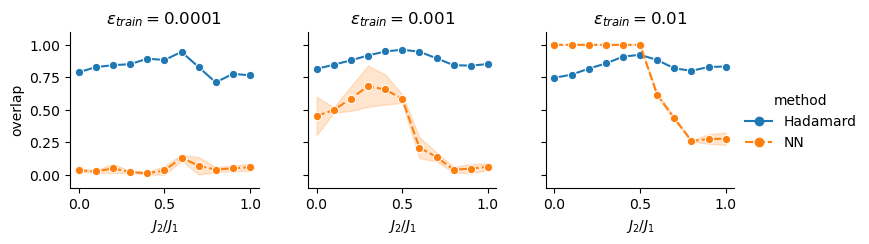

In [8]:
g = sns.relplot(
    pd.concat(
        [
            df_hadamard.assign(method="Hadamard").rename(
                columns={
                    "sample_power": "sampling_power_train",
                    "sign_overlap_test": "test_overlap",
                }
            ),
            # df.query("keep_terms > 100")
            # .loc[
            #     lambda _: _.groupby(["sampling_power_train", "lattice", "run", "J2", "eps_train"])[
            #         "overlap_predicted_vs_previous"
            #     ].idxmax()
            # ]
            # .assign(method="Fourier"),
            # df
            # .loc[
            #     lambda _: _.groupby(["sampling_power_train", "lattice", "run", "J2", "eps_train"])[
            #         "test_overlap"
            #     ].idxmax()
            # ]
            # .assign(method="Fourier-best"),
            df_nn.query("architecture == 'dense'")
            .loc[
                lambda _: _.groupby(
                    [
                        "sampling_power_train",
                        "lattice",
                        "start_timestamp",
                        "J2",
                        "eps_train",
                    ]
                )["test_overlap"].idxmax()
            ]
            .assign(method="NN"),
        ],
        axis=0,
    )
    .query(
        'lattice == "kagome2x4" '
        "and sampling_power_train == @sample_power "
        "and eps_train > 1e-5 "
        "and eps_train < 0.05"
    )
    .rename(
        columns={
            "J2": "$J_2/J_1$",
            "eps_train": r"$\varepsilon_{train}$",
            "test_overlap": "overlap",
            "test_accuracy": "accuracy",
        }
    )
    .melt(
        id_vars=["method", "$J_2/J_1$", r"$\varepsilon_{train}$", "start_timestamp"],
        value_vars=["overlap"],
        var_name="metric",
        value_name="score",
    ),
    x="$J_2/J_1$",
    y="score",
    kind="line",
    errorbar="sd",
    hue="method",
    row="metric",
    col=r"$\varepsilon_{train}$",
    style="method",
    markers=["o", "o"],
    height=2.5,
    facet_kws={"sharey": False},
)

g.axes[0, 0].set_ylabel("overlap")
# g.axes[1, 0].set_ylabel("accuracy")

# Customize column titles
for ax, title in zip(g.axes[0], g.col_names):
    ax.set_title(rf"$\varepsilon_{{train}} = {title}$")

# for ax, title in zip(g.axes[1], g.col_names):
#     ax.set_title("")

# Update y-limits for each row
for ax in g.axes[0, :]:
    ax.set_ylim(-0.1, 1.1)
# for ax in g.axes[1, :]:
#     ax.set_ylim(0.45, 1)

# Remove ticks and labels on each vertical axes except the leftmost ones
for row_axes in g.axes:
    for ax in row_axes[1:]:
        ax.set_ylabel("")
        ax.set_yticklabels([])
# plt.tight_layout()
# plt.savefig("fig/hadamard_vs_nn_kagome.png", dpi=300)

In [3]:
import lattice_symmetries as ls

In [13]:
[[x] for x in lattice.sites]

[[0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10],
 [11],
 [12],
 [13],
 [14],
 [15],
 [16],
 [17],
 [18],
 [19],
 [20],
 [21],
 [22],
 [23]]

In [2]:
lattice = KagomeLattice(2, 4)
outputs = []
sample_power = 2

for h in np.linspace(0, 1, 21):
    for J2 in [1]:
        system = spin_system(
            heisenberg_transversal_field(lattice, J2=J2, h=h),
            no_symmetries_basis(hamming_weight=None, spin_inversion=None),
        )
        wavefunction = system.ground_state
        transformed_wavefunction = hadamard_transform(wavefunction)
        outputs.append(
            evaluate_hadamard_learning_test_set(
                wavefunction=wavefunction,
                basis=system.basis,
                sample_power=sample_power,
                test_size=50000,
                eps_train=1e-2,
            )
            | {
                "h": h,
                "lattice": "kagome2x4",
                "overlap_with_transformed": transformed_wavefunction
                @ wavefunction
                / np.linalg.norm(wavefunction)
                / np.linalg.norm(transformed_wavefunction),
                "J2": J2,
            }
        )

2024-09-24 21:37:11.484 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-09-24 21:37:11.489 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-09-24 21:37:11.576 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-09-24 21:37:11.768 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-09-24 21:37:11.893 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-09-24 21:37:11.988 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-09-24 21:37:12.085 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-09-24 21:37:12.158 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-09-24 21:37:12.248 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-09-24 21:37:12.342 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-0

KeyboardInterrupt: 

In [16]:
pd.DataFrame(outputs)

,sample_size,eps_train,sample_power,test_size,accuracy_test,sign_overlap_test,h,lattice,overlap_with_transformed
0,24209,0.01,2,50000,0.51664,0.976885,0.00,kagome2x4,1.000000
1,160369,0.01,2,50000,0.50858,0.738833,0.05,kagome2x4,0.996768
2,164831,0.01,2,50000,0.50550,0.679732,0.10,kagome2x4,0.986985
3,166199,0.01,2,50000,0.51018,0.566816,0.15,kagome2x4,0.970322
4,167700,0.01,2,50000,0.49526,0.295856,0.20,kagome2x4,0.752855
5,167745,0.01,2,50000,0.49726,0.262367,0.25,kagome2x4,0.672910
6,167250,0.01,2,50000,0.49340,-0.157928,0.30,kagome2x4,-0.375174
7,167771,0.01,2,50000,0.50486,0.023834,0.35,kagome2x4,0.211589
8,167772,0.01,2,50000,0.50432,0.049577,0.40,kagome2x4,0.203024
9,167772,0.01,2,50000,0.50314,0.074121,0.45,kagome2x4,0.194435


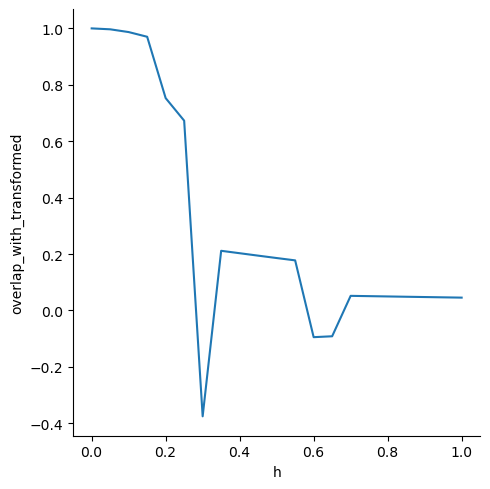

In [17]:
sns.relplot(pd.DataFrame(outputs), x="h", y="overlap_with_transformed", kind="line")

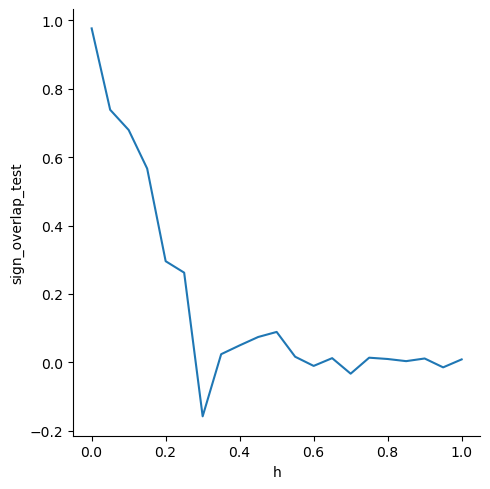

In [15]:
sns.relplot(pd.DataFrame(outputs), x="h", y="sign_overlap_test", kind="line")

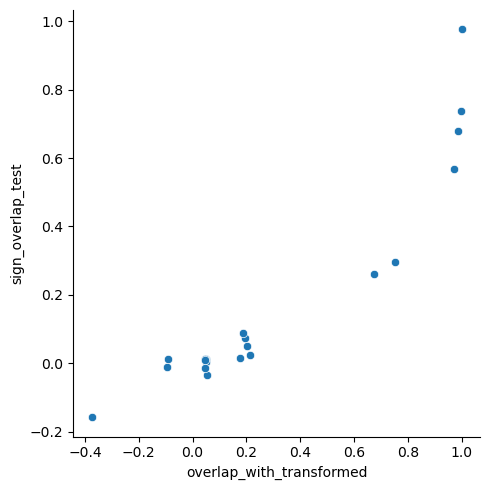

In [20]:
sns.relplot(pd.DataFrame(outputs), x="overlap_with_transformed", y="sign_overlap_test")

In [7]:
spin_system(
    heisenberg(lattice, J2=1),
    no_symmetries_basis(),
).ground_energy

2024-09-24 16:57:47.239 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


-43.039588992336185